<a href="https://colab.research.google.com/github/gibranfp/CursoAprendizajeProfundo/blob/2025-1/notebooks/1d_procesamiento_audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento de comandos de voz

---
Reconocimiento de comandos de voz a partir de un audio para decidir si la persona dijo:

“sí”, “no”, “arriba”, “abajo”, “encender”, “apagar”, etc.

La red basada en Transformers se encarga de mapear la secuencia de audio a una de esas clases.



## 1. Preparación

### 1.1 Bibliotecas

In [1]:
import random 

# audio
import librosa
import IPython as ip

# gráficas
import matplotlib.pyplot as plt
# arreglos multidimensionales
import numpy as np

# redes neuronales
import torch as th
import torch.nn as nn

# redes audio
import torchaudio
import torchaudio.transforms as T

# redes neuronales
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

# barras de progreso
from tqdm.auto import trange

#Counter
import collections

print(th.__version__)
print(torchaudio.__version__)
print(librosa.__version__)

2.5.1+cu121
2.5.1+cu121
0.11.0


c:\Users\Pablo\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Datos

In [2]:
DATA_DIR = 'datos'

# Se utiliza el conjunto de datos SPEECHCOMMANDS:
# https://pytorch.org/audio/stable/generated/torchaudio.datasets.SPEECHCOMMANDS.html#torchaudio.datasets.SPEECHCOMMANDS
ds = SPEECHCOMMANDS(DATA_DIR, download=True)

In [3]:
len(ds)

105829

## 3. Exploración

### 3.1 Examinar un ejemplo

In [4]:
waveform, sample_rate, label, id_spk, utt = ds[3078]

print(
  f'Etiqueta: {label}\n'
  f'Forma de onda: {waveform.shape}\n'
  f'Frecuencia de muestreo: {sample_rate}\n'
  f'Duración: {waveform.shape[1] / sample_rate}\n'
  f'Tipo: {waveform.dtype}\n'
)

Etiqueta: bed
Forma de onda: torch.Size([1, 14861])
Frecuencia de muestreo: 16000
Duración: 0.9288125
Tipo: torch.float32



In [5]:
waveform

tensor([[ 0.0002,  0.0004,  0.0002,  ..., -0.0002, -0.0003, -0.0003]])

### 3.2 Duración del conjunto

In [6]:
durations = []
for i in trange(len(ds)):
  waveform, sample_rate, label ,id_spk, utt = ds[i]
  num_channels, samples = waveform.shape
  durations.append(samples)

100%|██████████| 105829/105829 [09:59<00:00, 176.63it/s]


Duraciones
Counter({16000: 95394, 14336: 696, 15702: 649, 15604: 575, 15019: 575, 14861: 551, 14118: 503, 12288: 490, 13375: 455, 13654: 415, 12971: 381, 12056: 370, 10240: 295, 12632: 247, 13653: 239, 12970: 237, 11606: 235, 11605: 210, 15018: 208, 11889: 200, 15701: 198, 10922: 195, 10923: 170, 9557: 156, 11146: 144, 8192: 138, 8874: 136, 11888: 135, 12631: 127, 12136: 121, 11145: 107, 10402: 99, 12052: 86, 9558: 80, 10403: 77, 9659: 76, 8875: 69, 7509: 67, 9660: 57, 6826: 48, 8916: 45, 12132: 41, 6144: 33, 8173: 32, 8917: 31, 7430: 22, 15360: 18, 6687: 15, 8174: 15, 11976: 15, 12456: 13, 13995: 12, 13312: 12, 11947: 11, 5461: 11, 15531: 10, 7431: 10, 14678: 10, 12630: 9, 12212: 9, 12376: 9, 12800: 8, 9216: 7, 15872: 7, 14507: 7, 11776: 7, 14848: 7, 5201: 6, 13142: 6, 9899: 6, 12459: 6, 13141: 6, 12216: 6, 13483: 5, 11264: 5, 7510: 5, 12118: 5, 12536: 5, 5944: 5, 14677: 5, 6827: 5, 10581: 4, 12629: 4, 9046: 4, 4778: 4, 9387: 4, 15190: 4, 7168: 3, 15189: 3, 14490: 3, 7851: 3, 14166: 3

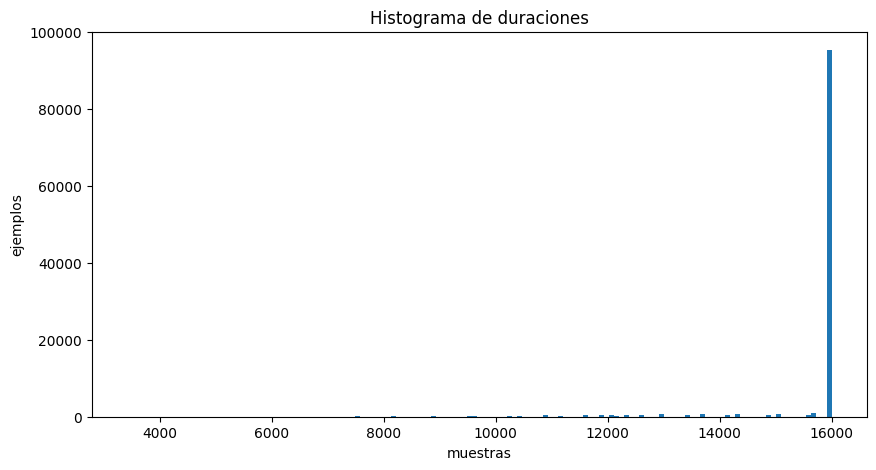

In [7]:
counter = collections.Counter(durations)

print('Duraciones')
print(counter)

plt.figure(figsize=(10, 5))
plt.hist(durations, bins=len(counter.keys())+1)
plt.bar(counter.keys(), counter.values())
plt.title('Histograma de duraciones')
plt.xlabel('muestras')
plt.ylabel('ejemplos')
plt.show()

In [8]:
# número mínimo de muestras
min_samples = min(counter.keys())
print(f"min samples: {min_samples}")
max_samples = max(counter.keys())
print(f"max samples: {max_samples}")

min samples: 3413
max samples: 16000


## 4. Formas de onda

### 4.1 Audio

In [9]:
# leemos el primer ejemplo
waveformA, sample_rateA, labelA, id_spkA, uttA = ds[1]

# comvertimos a numpy para ipython y librosa
waveformA_numpy = waveformA.flatten().numpy()

print(
    f'Etiqueta: {labelA}\n'
    f'Forma de onda (forma torch): {waveformA.shape}\n'
    f'Forma de onda (forma numpy): {waveformA_numpy.shape}\n'
    f'Frecuencia de muestreo: {sample_rateA}\n'
    f'Duración: {waveformA_numpy.shape[0] / sample_rateA}\n'
    f'Tipo: {waveformA.dtype}'
)

Etiqueta: backward
Forma de onda (forma torch): torch.Size([1, 16000])
Forma de onda (forma numpy): (16000,)
Frecuencia de muestreo: 16000
Duración: 1.0
Tipo: torch.float32


In [10]:
# reproducimos
ip.display.Audio(waveformA_numpy, rate=sample_rateA)

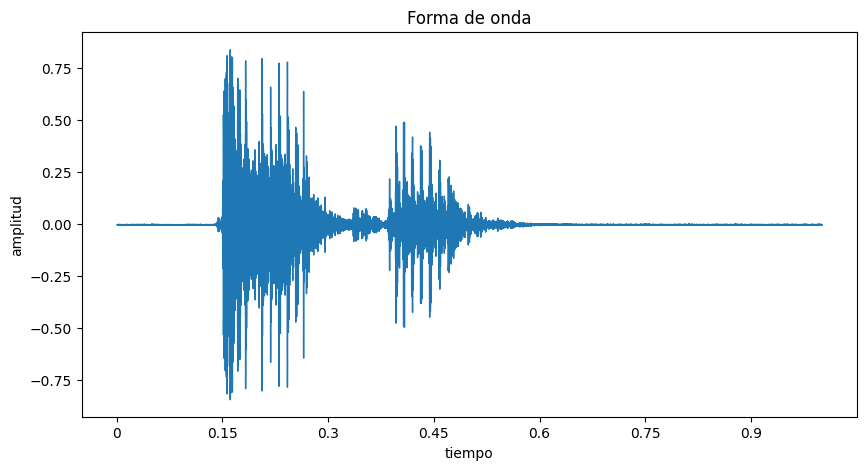

In [11]:
# graficamos la forma de onda
plt.figure(figsize=(10, 5))
librosa.display.waveshow(waveformA_numpy, sr=sample_rateA)
plt.title('Forma de onda')
plt.xlabel('tiempo')
plt.ylabel('amplitud')
plt.show()

In [12]:
# leemos el primer ejemplo
waveformB, sample_rateB, labelB, id_spkB, uttB = ds[3078]

# comvertimos a numpy para ipython y librosa
waveformB_numpy = waveformB.flatten().numpy()

print(
  f'Etiqueta: {labelB}\n'
  f'Forma de onda (forma torch): {waveformB.shape}\n'
  f'Forma de onda (forma numpy): {waveformB_numpy.shape}\n'
  f'Frecuencia de muestreo: {sample_rateB}\n'
  f'Duración: {waveformB_numpy.shape[0] / sample_rateB}\n'
  f'Tipo: {waveformB.dtype}'
)

Etiqueta: bed
Forma de onda (forma torch): torch.Size([1, 14861])
Forma de onda (forma numpy): (14861,)
Frecuencia de muestreo: 16000
Duración: 0.9288125
Tipo: torch.float32


In [13]:
# reproducimos
ip.display.Audio(waveformB_numpy, rate=sample_rateB)

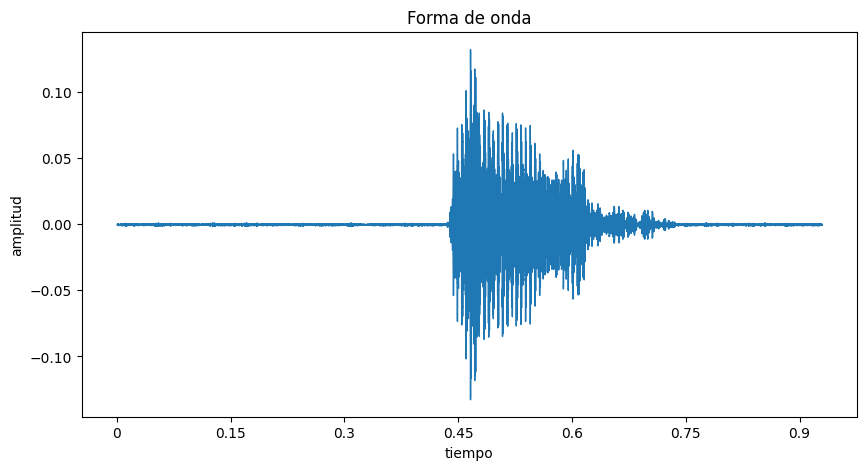

In [14]:
# graficamos la forma de onda
plt.figure(figsize=(10, 5))
librosa.display.waveshow(waveformB_numpy, sr=sample_rateB)
plt.title('Forma de onda')
plt.xlabel('tiempo')
plt.ylabel('amplitud')
plt.show()

## 5. Características

El valor de n_fft determina la resolución del eje de frecuencia.

hop_length determina la resolución del eje de tiempo. De forma predeterminada se utiliza el valor de n_fft // 4.

In [15]:
# tamaño de la ventana
n_fft = 1000
# tamaño del salto
hop_length = n_fft // 2

### 5.1 Espectrogramas

Para obtener la composición de frecuencia de una señal de audio que varía con el tiempo, puede usar torchaudio.transforms.Spectrogram().

Los humanos perciben la frecuencia de forma logarítmica.

In [16]:
spectrogram = T.Spectrogram(n_fft=n_fft, hop_length=hop_length)(waveformA)
print(spectrogram.shape, spectrogram.dtype)
spectrogram

torch.Size([1, 501, 33]) torch.float32


tensor([[[3.4630e-04, 2.9274e-05, 2.8580e-05,  ..., 1.0255e-05,
          1.8649e-05, 6.4235e-05],
         [3.4962e-04, 1.0071e-04, 2.9823e-05,  ..., 1.0178e-04,
          3.6574e-05, 1.6169e-04],
         [6.3828e-04, 1.0124e-04, 6.4328e-06,  ..., 4.3791e-04,
          1.5712e-04, 2.7300e-04],
         ...,
         [6.7521e-08, 1.2022e-07, 2.1205e-07,  ..., 9.6493e-07,
          1.1402e-06, 8.1128e-09],
         [9.5221e-08, 1.6604e-07, 1.5564e-07,  ..., 1.7882e-06,
          1.2326e-06, 2.1697e-07],
         [3.6251e-08, 8.1307e-08, 3.7848e-07,  ..., 9.6889e-07,
          1.1262e-06, 4.3512e-07]]])

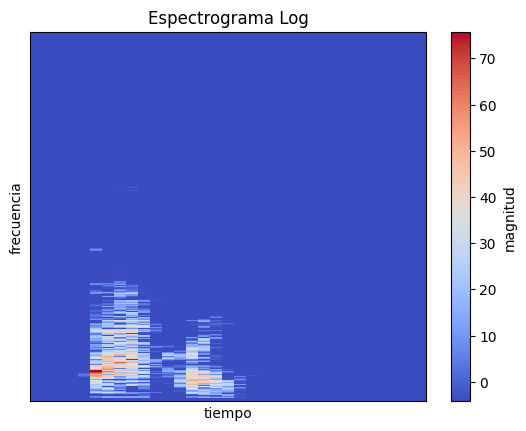

In [17]:
spectrogram_numpy = spectrogram.squeeze().numpy()
log_spectrogram = librosa.amplitude_to_db(spectrogram_numpy)

librosa.display.specshow(log_spectrogram,
                         sr=sample_rateA, hop_length=hop_length)
plt.title('Espectrograma Log')
plt.xlabel('tiempo')
plt.ylabel('frecuencia')
# Se muestra la barra de color para darnos una idea del rango de amplitudes en decibeles.
cbar = plt.colorbar()
cbar.set_label('magnitud', rotation=90)
plt.show()

### 5.2 Espectograma Log-Mel

Frecuencias a Escala de Mel

$m = 2595*log(1+\frac{f}{500})$

https://www.youtube.com/watch?v=9GHCiiDLHQ4


<img src="http://turing.iimas.unam.mx/~ivanvladimir/images/mfcc_fig5.png"/>

https://turing.iimas.unam.mx/~ivanvladimir/posts/mfcc/

In [18]:
mel_spectrogram = T.MelSpectrogram(n_fft=n_fft, hop_length=hop_length)(waveformA)
print(mel_spectrogram.shape, mel_spectrogram.dtype)
mel_spectrogram

torch.Size([1, 128, 33]) torch.float32


tensor([[[2.9521e-04, 8.5035e-05, 2.5183e-05,  ..., 8.5944e-05,
          3.0883e-05, 1.3653e-04],
         [5.1000e-04, 8.7933e-05, 9.2324e-06,  ..., 3.2841e-04,
          1.1784e-04, 2.2002e-04],
         [5.3278e-04, 3.4490e-05, 1.0678e-04,  ..., 1.9573e-04,
          1.2886e-04, 2.4424e-04],
         ...,
         [6.7079e-05, 7.0378e-05, 4.9343e-05,  ..., 6.4436e-05,
          5.0066e-05, 6.8437e-05],
         [2.4897e-05, 2.3971e-05, 3.0510e-05,  ..., 4.6032e-05,
          1.7484e-05, 2.6811e-05],
         [1.6118e-05, 7.5180e-06, 5.1918e-06,  ..., 1.5016e-05,
          1.1879e-05, 2.0226e-05]]])

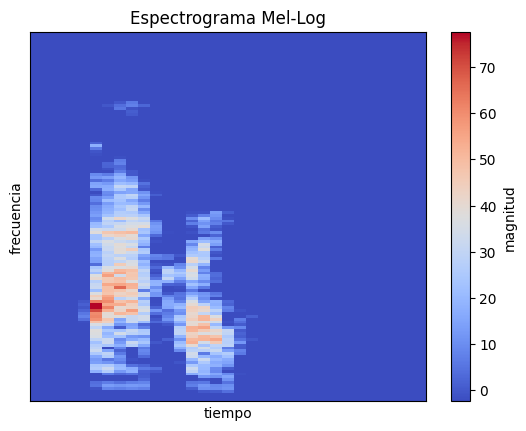

In [19]:
mel_spectrogram_numpy = mel_spectrogram.squeeze().numpy()
log_mel_spectrogram_numpy = librosa.amplitude_to_db(mel_spectrogram_numpy)

librosa.display.specshow(log_mel_spectrogram_numpy,
                         sr=sample_rateA, hop_length=hop_length)
plt.title('Espectrograma Mel-Log')
plt.xlabel('tiempo')
plt.ylabel('frecuencia')
cbar = plt.colorbar()
cbar.set_label('magnitud', rotation=90)
plt.show()

### 5.3 MFCCs (Mel-frequency cepstral coeficients)

1.- Separar la señal en pequeños tramos.

2.- A cada tramo aplicarle la Transformada de Fourier discreta y obtener la potencia espectral de la señal.

3.- Aplicar el banco de filtros correspondientes a la Escala Mel al espectro obtenido en el paso anterior y sumar las energías en cada uno de ellos.

4.- Tomar el logaritmo de todas las energías de cada frecuencia mel

5.-Aplicarle la transformada de coseno discreta a estos logaritmos.

https://turing.iimas.unam.mx/~ivanvladimir/posts/mfcc/

In [21]:
mfccs = T.MFCC()(waveformA)
print(mfccs.shape, mfccs.dtype)
mfccs

torch.Size([1, 40, 81]) torch.float32


tensor([[[-5.1596e+02, -5.2068e+02, -5.1357e+02,  ..., -4.9976e+02,
          -5.0227e+02, -5.0542e+02],
         [ 1.9111e+01,  1.3181e+01,  1.9767e+01,  ...,  2.2714e+01,
           2.5238e+01,  1.9226e+01],
         [ 1.3228e+01,  9.5514e+00,  1.3591e+01,  ...,  1.8591e+01,
           1.4602e+01,  2.0137e+01],
         ...,
         [ 3.5582e+00,  3.1715e+00,  2.6139e+00,  ..., -2.3913e+00,
           2.5416e+00, -3.9608e+00],
         [ 9.7919e-01,  1.7033e+00, -2.4975e-01,  ..., -3.5801e+00,
           5.0414e-01, -4.9371e+00],
         [-5.3154e-01,  1.4709e+00,  3.0776e-01,  ...,  1.9141e-01,
           4.2464e+00, -5.0865e+00]]])

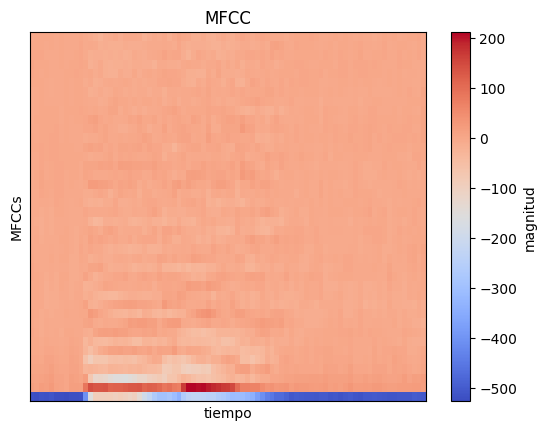

In [22]:
mfccs_numpy = mfccs.squeeze().numpy()

librosa.display.specshow(mfccs_numpy, sr=sample_rateA, hop_length=hop_length)
plt.title('MFCC')
plt.xlabel('tiempo')
plt.ylabel('MFCCs')
cbar = plt.colorbar()
cbar.set_label('magnitud', rotation=90)
plt.show()

## 6. Conjunto de Datos (Dataset)

In [24]:
# tamaño del lote
BATCH_SIZE = 32

# parámetros de audio
SECS = 1
SAMPLE_RATE = 16000

# parámetros FFT
N_FFT = 400
HOP_LENGTH = N_FFT // 2

# SpeechCommands classes
CLASSES = (
    'backward', 'bed', 'bird', 'cat', 'dog',
    'down', 'eight', 'five', 'follow', 'forward',
    'four', 'go', 'happy', 'house', 'learn',
    'left', 'marvin', 'nine', 'no', 'off',
    'on', 'one', 'right', 'seven', 'sheila',
    'six', 'stop', 'three', 'tree', 'two',
    'up', 'visual', 'wow', 'yes', 'zero'
)

NUM_CLASSES = len(CLASSES)
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASS_IDX)


def set_seed(seed = 0):
    """Initializes pseudo-random number generators."""
    random.seed(seed)
    np.random.seed(seed)
    th.manual_seed(seed)


# reproducibilidad
set_seed()

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


In [25]:
def label2index(label):
    return CLASS_IDX[label]

class MySpeechCommands(SPEECHCOMMANDS):
  def __init__(self, 
               root, 
               download = False, 
               subset = None,
               waveform_tsfm = None, 
               label_tsfm = None):
    super().__init__(root = root, download = download, subset = subset)
    self.waveform_tsfm = waveform_tsfm
    self.label_tsfm = label_tsfm

  def __getitem__(self, i):
    waveform, sample_rate, label, *_ = super().__getitem__(i)

    if self.waveform_tsfm:
      x = self.waveform_tsfm(waveform)
    
    if self.label_tsfm:
      y = self.label_tsfm(label)
      
    return x, y, label, sample_rate

### 6.1 Transformación para la forma de onda

define la trnasformación Mel

In [44]:
N_MELS = 64

class WaveformPadTruncate(nn.Module):
  def __init__(self, secs = SECS, sample_rate = SAMPLE_RATE):
    super().__init__()
    self.samples = secs * sample_rate

  def forward(self, waveform):
    samples = waveform.shape[1]

    if samples < self.samples:
      difference = self.samples - samples
      padding = th.zeros(1, difference)
      waveform = th.cat([waveform, padding], 1)

    elif samples > self.samples:
      start = random.randint(0, waveform.shape[1] - self.samples)
      # Devuelve un nuevo tensor que es una versión reducida del tensor de entrada.
      waveform = waveform.narrow(1, start, self.samples) # (dimension, start, length)

    return waveform
  
# número de bandas Mel por espectrograma
mel_tsfm = nn.Sequential(
    WaveformPadTruncate(secs=SECS, sample_rate=SAMPLE_RATE),
    T.MelSpectrogram(
        sample_rate=SAMPLE_RATE,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    ),
    T.AmplitudeToDB()
)

### 6.2 Dataset y Dataloader

In [45]:
# creamos un Dataset
ds = MySpeechCommands(
  # directorio de datos
  root = DATA_DIR,
  # llamada a log-Mel
  waveform_tsfm = mel_tsfm,
  # transformación de etiqueta
  label_tsfm = label2index,
)

# creamos un DataLoader
dl = DataLoader(
  # conjunto
  ds,
  # tamaño del lote
  batch_size = BATCH_SIZE,
  # desordenar
  shuffle = True)


In [56]:
class Transformer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True  
        )
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, need_weights=False):
        attn_output, attn_weights = self.self_attn(
            x, x, x,
            need_weights=need_weights,
            average_attn_weights=False  
        )
        x = self.ln1(x + self.dropout1(attn_output))
        ff_out = self.ff(x)
        x = self.ln2(x + self.dropout2(ff_out))

        if need_weights:
            return x, attn_weights  
        else:
            return x

### 6.3. Inspección del conjunto

In [48]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')

x shape=torch.Size([32, 1, 64, 81]) dtype=torch.float32
y shape=torch.Size([32]) dtype=torch.int64


In [50]:
# leemos un ejemplo
waveformB, sample_rateB, labelB, id_spkB = ds[3078]

# comvertimos a numpy para ipython y librosa
waveformB_numpy = waveformB.flatten().numpy()

print(
  f'Etiqueta: {labelB}\n'
  f'Forma de onda (forma torch): {waveformB.shape}\n'
  f'Forma de onda (forma numpy): {waveformB_numpy.shape}\n'
  f'Frecuencia de muestreo: {sample_rateB}\n'
  f'Duración: {waveformB_numpy.shape[0] / sample_rateB}\n'
  f'Tipo: {waveformB.dtype}'
)

Etiqueta: bed
Forma de onda (forma torch): torch.Size([1, 64, 81])
Forma de onda (forma numpy): (5184,)
Frecuencia de muestreo: 1
Duración: 5184.0
Tipo: torch.float32


In [57]:
class VozTransformer(nn.Module):
    def __init__(self,
                 n_mels=N_MELS,
                 d_model=128,
                 n_heads=4,
                 n_layers=4,
                 num_classes=NUM_CLASSES,
                 dropout=0.1,
                 max_frames=200):
        super().__init__()
        self.d_model = d_model
        self.max_frames = max_frames

        # el vector columna a espacio embedding
        self.input_proj = nn.Linear(n_mels, d_model)

        # embedding de posicion aprendido
        self.pos_emb = nn.Embedding(max_frames, d_model)

        # pila de bloques transformer 
        self.blocks = nn.ModuleList([
            Transformer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])

        # clasificador final
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

    def forward(self, x, return_attn=False):
        x = x.squeeze(1)
        x = x.transpose(1, 2)

        B, T, M = x.shape

        if T > self.max_frames:
            x = x[:, :self.max_frames, :]
            T = self.max_frames

        h = self.input_proj(x)  


        pos = th.arange(T, device=h.device).unsqueeze(0).expand(B, T)
        h = h + self.pos_emb(pos)

        attn_maps = {}

        for i, block in enumerate(self.blocks):
            need = return_attn and (i == 0 or i == len(self.blocks) - 1)
            if need:
                h, attn = block(h, need_weights=True)  
                attn_maps[f"layer_{i}"] = attn
            else:
                h = block(h, need_weights=False)

        h_mean = h.mean(dim=1)  

        logits = self.classifier(h_mean)  

        if return_attn:
            return logits, attn_maps
        return logits


In [58]:
DC = "cuda:0" if th.cuda.is_available() else "cpu"

modelo = VozTransformer(
    n_mels=N_MELS,
    d_model=128,
    n_heads=4,
    n_layers=4,
    num_classes=NUM_CLASSES,
    dropout=0.1,
    max_frames=200  
).to(DC)


In [66]:
criterio = nn.CrossEntropyLoss()
opt = th.optim.AdamW(modelo.parameters(), lr=1e-3, weight_decay=1e-4)

N_EPOCAS = 30  

for ep in range(N_EPOCAS):
    modelo.train()
    loss_acum = 0.0
    correctos = 0
    total = 0

    for x, y, label_str, sr in dl:
        x = x.to(DC)              
        y = y.to(DC).long()        

        opt.zero_grad()
        logits = modelo(x)         
        loss = criterio(logits, y)
        loss.backward()
        opt.step()

        loss_acum += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        correctos += (pred == y).sum().item()
        total += x.size(0)

    print(f"Época {ep+1}/{N_EPOCAS} - Loss: {loss_acum/total:.4f} - Acc: {correctos/total:.3f}")


Época 1/30 - Loss: 0.5976 - Acc: 0.824
Época 2/30 - Loss: 0.5444 - Acc: 0.839
Época 3/30 - Loss: 0.7436 - Acc: 0.782
Época 4/30 - Loss: 0.6433 - Acc: 0.810
Época 5/30 - Loss: 0.7666 - Acc: 0.774
Época 6/30 - Loss: 0.6811 - Acc: 0.800
Época 7/30 - Loss: 0.5977 - Acc: 0.823
Época 8/30 - Loss: 0.5829 - Acc: 0.828
Época 9/30 - Loss: 0.6835 - Acc: 0.798
Época 10/30 - Loss: 0.6210 - Acc: 0.815
Época 11/30 - Loss: 0.6061 - Acc: 0.821
Época 12/30 - Loss: 0.6269 - Acc: 0.814
Época 13/30 - Loss: 0.5892 - Acc: 0.823
Época 14/30 - Loss: 0.5273 - Acc: 0.842
Época 15/30 - Loss: 0.4860 - Acc: 0.854
Época 16/30 - Loss: 0.4426 - Acc: 0.868
Época 17/30 - Loss: 0.4343 - Acc: 0.871
Época 18/30 - Loss: 0.4191 - Acc: 0.874
Época 19/30 - Loss: 0.4210 - Acc: 0.874
Época 20/30 - Loss: 0.4055 - Acc: 0.878
Época 21/30 - Loss: 0.4303 - Acc: 0.871
Época 22/30 - Loss: 0.4557 - Acc: 0.863
Época 23/30 - Loss: 0.3824 - Acc: 0.885
Época 24/30 - Loss: 0.4346 - Acc: 0.870
Época 25/30 - Loss: 0.4237 - Acc: 0.873
Época 26/

In [68]:
# guardar el modelo
import torch as th
th.save(modelo.state_dict(), "recomandovoz.pth")
print("modelo guardado ")


modelo guardado 


### Visualización de mapas de atención (primera y última capa)


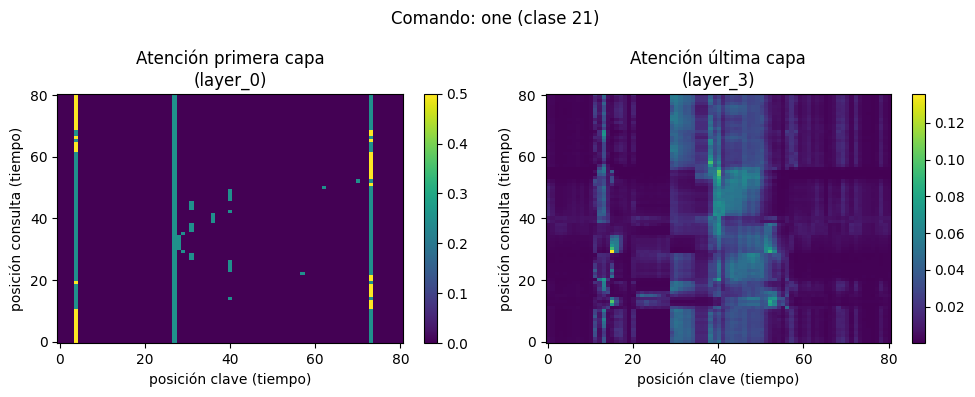

In [71]:
modelo.eval()

x_batch, y_batch, labels_batch, sr_batch = next(iter(dl))

x = x_batch[0:1].to(DC)    
y = y_batch[0].item()
label_str = labels_batch[0]

with th.no_grad():
    logits, attn_maps = modelo(x, return_attn=True)

layer_ids = sorted(attn_maps.keys(), key=lambda s: int(s.split("_")[-1]))
first_layer = layer_ids[0]
last_layer  = layer_ids[-1]

attn_first = attn_maps[first_layer][0].mean(dim=0).cpu()  
attn_last  = attn_maps[last_layer][0].mean(dim=0).cpu()   

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(attn_first, aspect='auto', origin='lower')
axs[0].set_title(f'Atención primera capa\n({first_layer})')
axs[0].set_xlabel('posición clave (tiempo)')
axs[0].set_ylabel('posición consulta (tiempo)')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(attn_last, aspect='auto', origin='lower')
axs[1].set_title(f'Atención última capa\n({last_layer})')
axs[1].set_xlabel('posición clave (tiempo)')
axs[1].set_ylabel('posición consulta (tiempo)')
plt.colorbar(im1, ax=axs[1])

plt.suptitle(f'Comando: {label_str} (clase {y})')
plt.tight_layout()
plt.show()


### log-Mel correspondiente

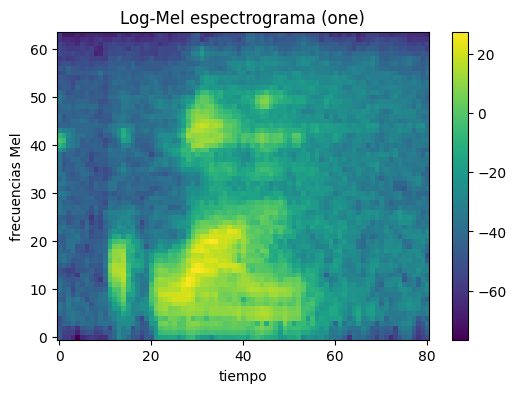

In [72]:
mel = x_batch[0, 0].cpu().numpy()  
plt.figure(figsize=(6, 4))
plt.imshow(mel, aspect='auto', origin='lower')
plt.title(f'Log-Mel espectrograma ({label_str})')
plt.xlabel('tiempo')
plt.ylabel('frecuencias Mel')
plt.colorbar()
plt.show()


### Guardar los logMel y las atenciones
para ello se crean dos carpetas para guardar cada imagen y espectrograma

10 veces para tener evidencia

In [ ]:
import os
os.makedirs("reco_mel", exist_ok=True)
os.makedirs("reco_atencion", exist_ok=True)

In [87]:
modelo.eval()

x_batch, y_batch, labels_batch, sr_batch = next(iter(dl))

x = x_batch[0:1].to(DC)    
y = y_batch[0].item()
label_str = labels_batch[0]

with th.no_grad():
    logits, attn_maps = modelo(x, return_attn=True)


mel = x_batch[0, 0].cpu().numpy()  

plt.figure(figsize=(6, 4))
plt.imshow(mel, aspect='auto', origin='lower')
plt.title(f'Log-Mel espectrograma ({label_str})')
plt.xlabel('tiempo')
plt.ylabel('frecuencias Mel')
plt.colorbar()

fname_mel = os.path.join("reco_mel", f"{label_str}_mel.png")
plt.savefig(fname_mel, dpi=150, bbox_inches='tight')

plt.close()

layer_ids = sorted(attn_maps.keys(), key=lambda s: int(s.split("_")[-1]))
first_layer = layer_ids[0]
last_layer  = layer_ids[-1]


attn_first = attn_maps[first_layer][0].mean(dim=0).cpu() 
attn_last  = attn_maps[last_layer][0].mean(dim=0).cpu()   

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow(attn_first, aspect='auto', origin='lower')
axs[0].set_title(f'Atención primera capa\n({first_layer})')
axs[0].set_xlabel('posición clave (tiempo)')
axs[0].set_ylabel('posición consulta (tiempo)')
plt.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(attn_last, aspect='auto', origin='lower')
axs[1].set_title(f'Atención última capa\n({last_layer})')
axs[1].set_xlabel('posición clave (tiempo)')
axs[1].set_ylabel('posición consulta (tiempo)')
plt.colorbar(im1, ax=axs[1])

plt.suptitle(f'Comando: {label_str} (clase {y})')
plt.tight_layout()

fname_attn = os.path.join("reco_atencion", f"{label_str}_attn.png")
plt.savefig(fname_attn, dpi=150, bbox_inches='tight')
plt.close()

print("liston mi buen")

liston mi buen
